<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Program-%20Substitution%20and%20transposition%20techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Text: Median housing value average is $207300.91 with total rooms 44942295.0

Substitution (Caesar Cipher): Phgldq krxvlqj ydoxh dyhudjh lv $207300.91 zlwk wrwdo urrpv 44942295.0

Transposition (Rail Fence): Mda osn au vrg s$0309 ihttlros4929.einhuigvleaeaei 270.1wt oa om 44250


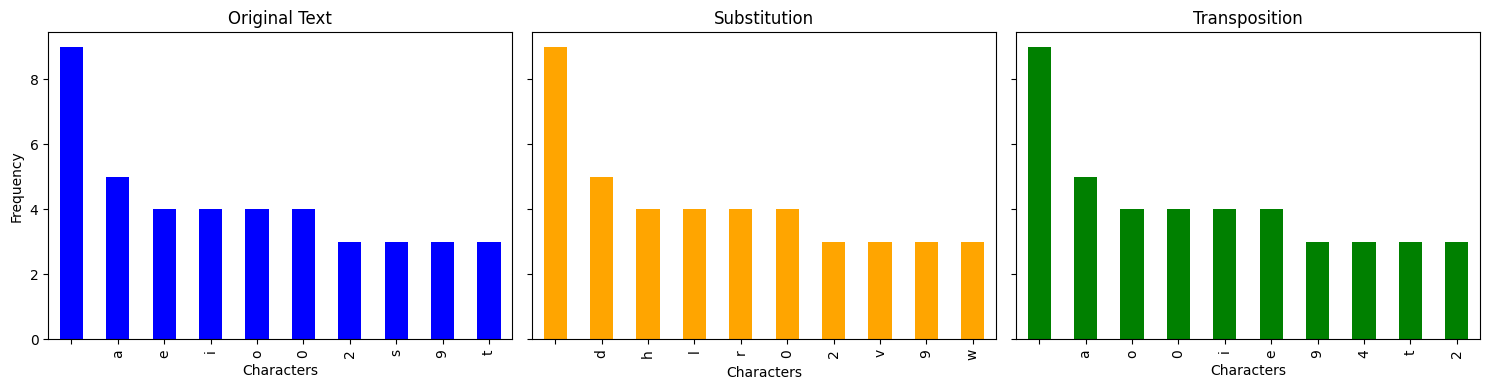

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset from Colab sample_data
df = pd.read_csv('sample_data/california_housing_train.csv')

# Create a sample text string using housing data insights
sample_text = f"Median housing value average is ${df['median_house_value'].mean():.2f} with total rooms {df['total_rooms'].sum()}"
print("Original Text:", sample_text)

# 2. Substitution Technique: Caesar Cipher (Shift by 3)
def caesar_encrypt(text, shift):
    result = ""
    for char in text:
        if char.isalpha():
            ascii_offset = ord('A') if char.isupper() else ord('a')
            result += chr((ord(char) - ascii_offset + shift) % 26 + ascii_offset)
        else:
            result += char
    return result

sub_cipher = caesar_encrypt(sample_text, 3)
print("\nSubstitution (Caesar Cipher):", sub_cipher)

# 3. Transposition Technique: Rail Fence Cipher (2 rails)
def rail_fence_encrypt(text, rails=2):
    if rails == 1 or not text:
        return text

    fence = [[] for _ in range(rails)]
    rail_idx = 0
    direction = 1 # 1 for down, -1 for up

    for char in text:
        fence[rail_idx].append(char)

        # Change direction if at the top or bottom rail
        if rail_idx == rails - 1:
            direction = -1
        elif rail_idx == 0:
            direction = 1

        rail_idx += direction # Move to the next rail

    return "".join("".join(r) for r in fence)

trans_cipher = rail_fence_encrypt(sample_text, 2)
print("\nTransposition (Rail Fence):", trans_cipher)

# 4. Visualize Insights: Character frequency distribution comparison
def get_freq(t):
    return pd.Series(list(t)).value_counts()

orig_f = get_freq(sample_text)
sub_f = get_freq(sub_cipher)
trans_f = get_freq(trans_cipher)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
orig_f.head(10).plot(kind='bar', ax=axes[0], color='blue', title='Original Text')
sub_f.head(10).plot(kind='bar', ax=axes[1], color='orange', title='Substitution')
trans_f.head(10).plot(kind='bar', ax=axes[2], color='green', title='Transposition')

for ax in axes:
    ax.set_xlabel('Characters')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()